# Expression Decoder
Trains an MLP: **(AlphaGenome binned track, scVI cell type embedding) → scalar gene expression**

In [1]:
!pip install -q pandas pyarrow

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Configuration

In [5]:
ORGANS = ['heart']
ASSAY  = '10X'
ROOT   = '/content/drive/MyDrive'

HIDDEN_DIMS   = [256, 128]
DROPOUT       = 0.2
LEARNING_RATE = 1e-3
BATCH_SIZE    = 512
EPOCHS        = 50
VAL_SPLIT     = 0.3

## Load Data

In [6]:
# Load each organ's AlphaGenome features and scVI embeddings
organ_data = {}
for organ in ORGANS:
    ag = np.load(f'{ROOT}/{organ}_{ASSAY}_alphagenome_features.npz', allow_pickle=True)
    cell_type_ids = ag['cell_type_ids']

    scvi_df = pd.read_parquet(f'{ROOT}/{organ}_{ASSAY}_cell_type_embeds.parquet')
    scvi_cols = [c for c in scvi_df.columns if c.startswith('scvi_')]

    organ_data[organ] = {
        'features':  ag['features'],                                          # [n_ct, n_genes, n_bins]
        'labels':    ag['labels'],                                            # [n_ct, n_genes]
        'gene_ids':  ag['gene_ids'],                                          # [n_genes]
        'scvi':      scvi_df.loc[cell_type_ids, scvi_cols].values.astype(np.float32),  # [n_ct, scvi_dim]
        'n_ct':      len(cell_type_ids),
    }
    print(f'{organ}: features={ag["features"].shape}  cell_types={len(cell_type_ids)}')

# n_bins and scvi_dim are the same across organs
n_bins   = next(iter(organ_data.values()))['features'].shape[2]
scvi_dim = next(iter(organ_data.values()))['scvi'].shape[1]
print(f'\nn_bins={n_bins}  scvi_dim={scvi_dim}')

heart: features=(15, 5000, 1024)  cell_types=15

n_bins=1024  scvi_dim=50


## Dataset
Each sample is a **(cell type, gene)** pair. Train/val split on **genes** to avoid leaking genomic context.

In [7]:
# Split on gene_id strings so the same gene is in the same split across all organs
all_gene_ids = sorted(set(gid for d in organ_data.values() for gid in d['gene_ids']))
rng          = np.random.default_rng(42)
shuffled     = rng.permutation(all_gene_ids)
split        = int(len(shuffled) * (1 - VAL_SPLIT))
train_gene_set, val_gene_set = set(shuffled[:split]), set(shuffled[split:])

# Fit sequence scaler on training features across all organs, then normalize each organ
seq_scaler = StandardScaler().fit(np.concatenate([
    d['features'][:, [i for i, g in enumerate(d['gene_ids']) if g in train_gene_set], :].reshape(-1, n_bins)
    for d in organ_data.values()
]))
scvi_scaler = StandardScaler().fit(np.concatenate([d['scvi'] for d in organ_data.values()]))

for d in organ_data.values():
    n_ct, n_genes = d['features'].shape[:2]
    d['features_norm'] = seq_scaler.transform(d['features'].reshape(-1, n_bins)).reshape(n_ct, n_genes, n_bins).astype(np.float32)
    d['scvi_norm']     = scvi_scaler.transform(d['scvi']).astype(np.float32)

class ExpressionDataset(Dataset):
    def __init__(self, gene_set):
        # Flat list of (organ, ct_idx, gene_idx) for genes in this split
        self.samples = [
            (organ, ct, g_idx)
            for organ, d in organ_data.items()
            for g_idx, g_id in enumerate(d['gene_ids']) if g_id in gene_set
            for ct in range(d['n_ct'])
        ]
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        organ, ct, g = self.samples[idx]
        d = organ_data[organ]
        x = torch.cat([torch.tensor(d['features_norm'][ct, g]), torch.tensor(d['scvi_norm'][ct])])
        y = torch.tensor(d['labels'][ct, g], dtype=torch.float32)
        return x, y

train_loader = DataLoader(ExpressionDataset(train_gene_set), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(ExpressionDataset(val_gene_set),   batch_size=BATCH_SIZE)
print(f'Train: {len(train_loader.dataset):,}  Val: {len(val_loader.dataset):,}')

Train: 52,500  Val: 22,500


## Model

In [8]:
class ExpressionDecoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout):
        super().__init__()
        dims = [input_dim] + hidden_dims
        layers = [l for i in range(len(dims)-1) for l in (nn.Linear(dims[i], dims[i+1]), nn.ReLU(), nn.Dropout(dropout))]
        layers.append(nn.Linear(hidden_dims[-1], 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(-1)

model = ExpressionDecoder(n_bins + scvi_dim, HIDDEN_DIMS, DROPOUT).to(device)
print(f'Input: {n_bins} bins + {scvi_dim} scVI = {n_bins + scvi_dim}')

Input: 1024 bins + 50 scVI = 1074


## Train

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn   = nn.MSELoss()
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(x)
    train_loss /= len(train_loader.dataset)

    model.eval()
    with torch.no_grad():
        val_loss = sum(loss_fn(model(x.to(device)), y.to(device)).item() * len(x) for x, y in val_loader)
    val_loss /= len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:>3}/{EPOCHS}  train={train_loss:.4f}  val={val_loss:.4f}')

Epoch   1/50  train=3.1563  val=3.2203
Epoch   5/50  train=1.5562  val=3.3875
Epoch  10/50  train=1.2271  val=3.4313
Epoch  15/50  train=1.0490  val=3.4257
Epoch  20/50  train=0.9398  val=3.4514
Epoch  25/50  train=0.8590  val=3.4336
Epoch  30/50  train=0.8002  val=3.4250
Epoch  35/50  train=0.7653  val=3.4104
Epoch  40/50  train=0.7254  val=3.4051
Epoch  45/50  train=0.6710  val=3.4333
Epoch  50/50  train=0.6475  val=3.4996


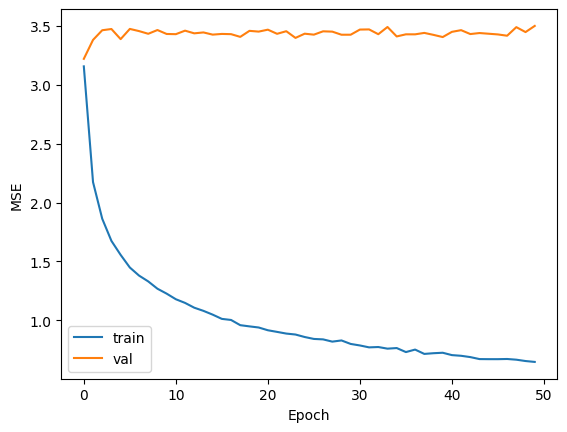

In [10]:
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.show()

## Evaluate

Pearson r: 0.2958  RMSE: 1.8707


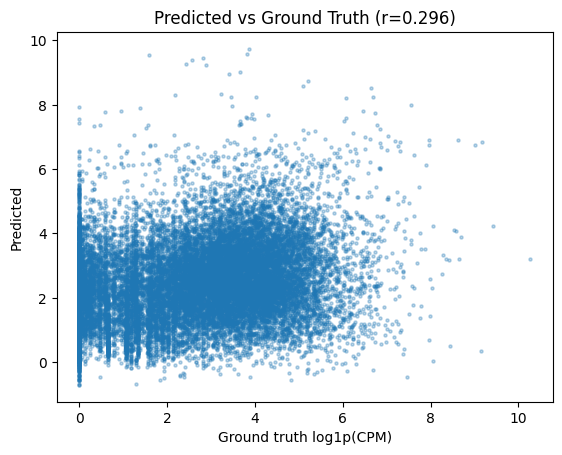

In [11]:
model.eval()
with torch.no_grad():
    preds   = np.concatenate([model(x.to(device)).cpu().numpy() for x, _ in val_loader])
    targets = np.concatenate([y.numpy() for _, y in val_loader])

r, _ = pearsonr(preds, targets)
print(f'Pearson r: {r:.4f}  RMSE: {np.sqrt(np.mean((preds - targets)**2)):.4f}')

plt.scatter(targets, preds, alpha=0.3, s=5)
plt.xlabel('Ground truth log1p(CPM)'); plt.ylabel('Predicted')
plt.title(f'Predicted vs Ground Truth (r={r:.3f})')
plt.show()

## Save Model

In [75]:
# torch.save(model.state_dict(), f'{ROOT}/{"_".join(ORGANS)}_{ASSAY}_decoder.pt')
# print(f'Saved {"_".join(ORGANS)}_{ASSAY}_decoder.pt to My Drive')